In [1]:
import os

if os.getcwd().endswith("scripts"):
    os.chdir("..")
os.getcwd()

'/mnt/mergerfs/yuzihan/MergedWorkSpace/44-AI4Astronomy/AI4Astronomy'

In [8]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from argparse import Namespace
from scipy.optimize import curve_fit
from sr_agent.utils.plot import get_fig
from scripts.run_science2022_sr_agent import build_task
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


exp_path = Path("logs/run_science2022_sr_agent/20260625_run_science2022_sr_agent_091645_SIM1")
args = Namespace(**json.load(open(exp_path / "args.json", encoding="utf-8")))
print(
    f"source={args.source!r}, "
)

X, y, problem = build_task(args)
data = X | y
data


source='all', 


{'source': array(['FRB20121102A', 'FRB20121102A', 'FRB20121102A', 'FRB20121102A',
        'FRB20180301A', 'FRB20180301A', 'FRB20180301A', 'FRB20180301A',
        'FRB20180301A', 'FRB20180301A', 'FRB20180301A', 'FRB20180916B',
        'FRB20180916B', 'FRB20180916B', 'FRB20180916B', 'FRB20190303A',
        'FRB20190303A', 'FRB20190303A', 'FRB20190303A', 'FRB20190417A',
        'FRB20190417A', 'FRB20190417A', 'FRB20190417A', 'FRB20190417A',
        'FRB20190520B', 'FRB20190520B', 'FRB20190520B', 'FRB20190520B',
        'FRB20190604A', 'FRB20190711A', 'FRB20190711A', 'FRB20190711A',
        'FRB20201124A', 'FRB20201124A', 'FRB20201124A', 'FRB20201124A',
        'FRB20201124A', 'FRB20201124A', 'FRB20201124A', 'FRB20201124A',
        'FRB20201124A', 'FRB20201124A', 'FRB20201124A', 'FRB20201124A',
        'FRB20201124A', 'FRB20201124A', 'FRB20201124A', 'FRB20201124A',
        'FRB20201124A', 'FRB20201124A', 'FRB20201124A', 'FRB20201124A'],
       dtype='<U12'),
 'frequency_mhz': array([1250. 

In [114]:
# AI-discovered formula from the original run with polynomial_fit enabled.
def foo():
    def model_code(data):
        import numpy as np
        
        sources = data['source']
        lamb = np.array(data['lambda_m'])
        
        # Fit per-source parameters
        unique_sources = sorted(set(sources))
        source_to_params = {}
        
        for src in unique_sources:
            mask = np.array([s == src for s in sources])
            l = lamb[mask]
            y = np.array(data['linear_polarization_fraction'])[mask]
            
            if len(y) >= 2:
                X = np.column_stack([np.ones(len(y)), l**4])
                coeffs = np.linalg.lstsq(X, np.log(y), rcond=None)[0]
                source_to_params[src] = {'a': coeffs[0], 'b': coeffs[1]}
            else:
                # For single-point sources, assume b=0 and a=log(LPF)
                source_to_params[src] = {'a': np.log(y[0]), 'b': 0.0}
        
        return {
            'source_to_params': source_to_params,
            'unique_sources': unique_sources
        }

    def predict_code(data, model):
        import numpy as np
        
        sources = data['source']
        lamb = np.array(data['lambda_m'])
        
        predictions = np.zeros(len(sources))
        for i, src in enumerate(sources):
            params = model['source_to_params'][src]
            predictions[i] = np.exp(params['a'] + params['b'] * lamb[i]**4)
        
        return predictions


    def format_model_code(model):
        lines = []
        for src in model['unique_sources']:
            p = model['source_to_params'][src]
            lines.append(f"{src}: LPF = exp({p['a']:.6f} + {p['b']:.6f}*lambda^4)")
        return "\n".join(lines)


    model = model_code(data)

    def f_ai(data):
        return predict_code(data, model)

    return f_ai, model

f_ai, model = foo()

In [113]:
def foo():
    def model_code(data):
        import numpy as np
        # Fit per-source exponential lambda^4 model
        sources = np.array(data['source'])
        lamb = np.array(data['lambda_m'])
        lpf = np.array(data['linear_polarization_fraction'])
        
        # For each source, fit ln(LPF) = a + b * lambda^4
        unique_sources = sorted(set(sources))
        source_params = {}
        for src in unique_sources:
            mask = sources == src
            l = lamb[mask]
            y = lpf[mask]
            if len(y) >= 2:
                X = np.column_stack([np.ones(len(y)), l**4])
                coeffs = np.linalg.lstsq(X, np.log(y), rcond=None)[0]
                source_params[src] = coeffs
            else:
                source_params[src] = np.array([np.log(y[0]), 0.0])
            source_params[src][0] = 0.0
        
        return source_params

    def predict_code(data, model):
        import numpy as np
        sources = np.array(data['source'])
        lamb = np.array(data['lambda_m'])
        preds = np.zeros(len(sources))
        for i, src in enumerate(sources):
            a, b = model[src]
            preds[i] = np.exp(a + b * lamb[i]**4)
        return preds

    model = model_code(data)
    
    def f_ai(data):
        return predict_code(data, model)
    
    return f_ai, model

f_ai2, model2 = foo()

In [135]:
def foo():
    import numpy as np

    def model_code(data):
        sources = data['source']
        lam = np.array(data['lambda_m'])
        L = np.array(data['linear_polarization_fraction'])
        
        # Model: L = exp(-K_s * lambda^4) where K_s is source-dependent
        unique_sources = sorted(set(sources))
        source_to_idx = {s: i for i, s in enumerate(unique_sources)}
        
        # Fit K for each source: K = -log(L) / lambda^4
        K_sums = np.zeros(len(unique_sources))
        counts = np.zeros(len(unique_sources))
        
        for s, l, Lval in zip(sources, lam, L):
            if Lval > 0.001:
                idx = source_to_idx[s]
                K_sums[idx] += -np.log(Lval) / (l**4)
                counts[idx] += 1
        
        K_vals = K_sums / np.maximum(counts, 1)
        
        return {'K_vals': K_vals, 'source_to_idx': source_to_idx}

    import numpy as np

    def predict_code(data, model):
        K_vals = model['K_vals']
        source_to_idx = model['source_to_idx']
        lam = np.array(data['lambda_m'])
        
        pred = []
        for s, l in zip(data['source'], lam):
            idx = source_to_idx.get(s, 0)
            K = K_vals[idx]
            pred.append(np.exp(-K * l**4))
        return np.array(pred)
    
    model = model_code(data)
    
    def f_ai(data):
        return predict_code(data, model)

    return f_ai, model

f_ai3, model3 = foo()

In [159]:
def foo():    
    import numpy as np

    def model_code(data):
        # Pre-compute optimal parameters using brute force
        sources = data['source']
        lam = np.array(data['lambda_m'], dtype=float)
        pol = np.array(data['linear_polarization_fraction'], dtype=float)
        
        unique_sources = sorted(set(sources))
        n_sources = len(unique_sources)
        source_to_idx = {s: i for i, s in enumerate(unique_sources)}
        
        # Fit L = exp(-k * lambda^2) per source
        K = np.zeros(n_sources)
        for src in unique_sources:
            idx_list = [i for i, s in enumerate(sources) if s == src]
            if len(idx_list) < 2:
                K[source_to_idx[src]] = 0.0
                continue
            l = lam[idx_list]
            p = pol[idx_list]
            # Use simple least squares on log-transformed data
            # log(L) = -k * lambda^2
            # -log(L) / lambda^2 = k
            valid = (p > 0) & (l > 0)
            if np.sum(valid) >= 2:
                k_est = np.mean(-np.log(p[valid]) / (l[valid]**2))
                K[source_to_idx[src]] = max(k_est, 0.01)
            else:
                K[source_to_idx[src]] = 0.01
        
        model = {
            'source_to_idx': source_to_idx,
            'K': K.tolist()
        }
        return model

    
    import numpy as np

    def predict_code(data, model):
        sources = data['source']
        lam = np.array(data['lambda_m'], dtype=float)
        source_to_idx = model['source_to_idx']
        K = np.array(model['K'])
        
        pred = np.zeros(len(lam))
        for i, s in enumerate(sources):
            idx = source_to_idx[s]
            pred[i] = np.exp(-K[idx] * lam[i]**2)
        return pred
    
    model = model_code(data)
    
    def f_ai(data):
        return predict_code(data, model)

    return f_ai, model

f_ai4, model4 = foo()

In [160]:
y_true = data['linear_polarization_fraction']
df_list = []

for name, fn in [
    ('AI1', f_ai),
    # ('AI2', f_ai2),
    ('AI3', f_ai3),
    ('AI4', f_ai4),
]:
    y_pred = fn(data)
    df_list.append({
        'model': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MAE': mean_absolute_error(y_true, y_pred),
    })

df_metrics = pd.DataFrame(df_list).set_index('model').sort_values('R2')
df_metrics


,R2,RMSE,MAE
model,,,
AI3,0.713403,0.130723,0.075893
AI4,0.855117,0.092944,0.072846
AI1,0.954318,0.052190,0.038298


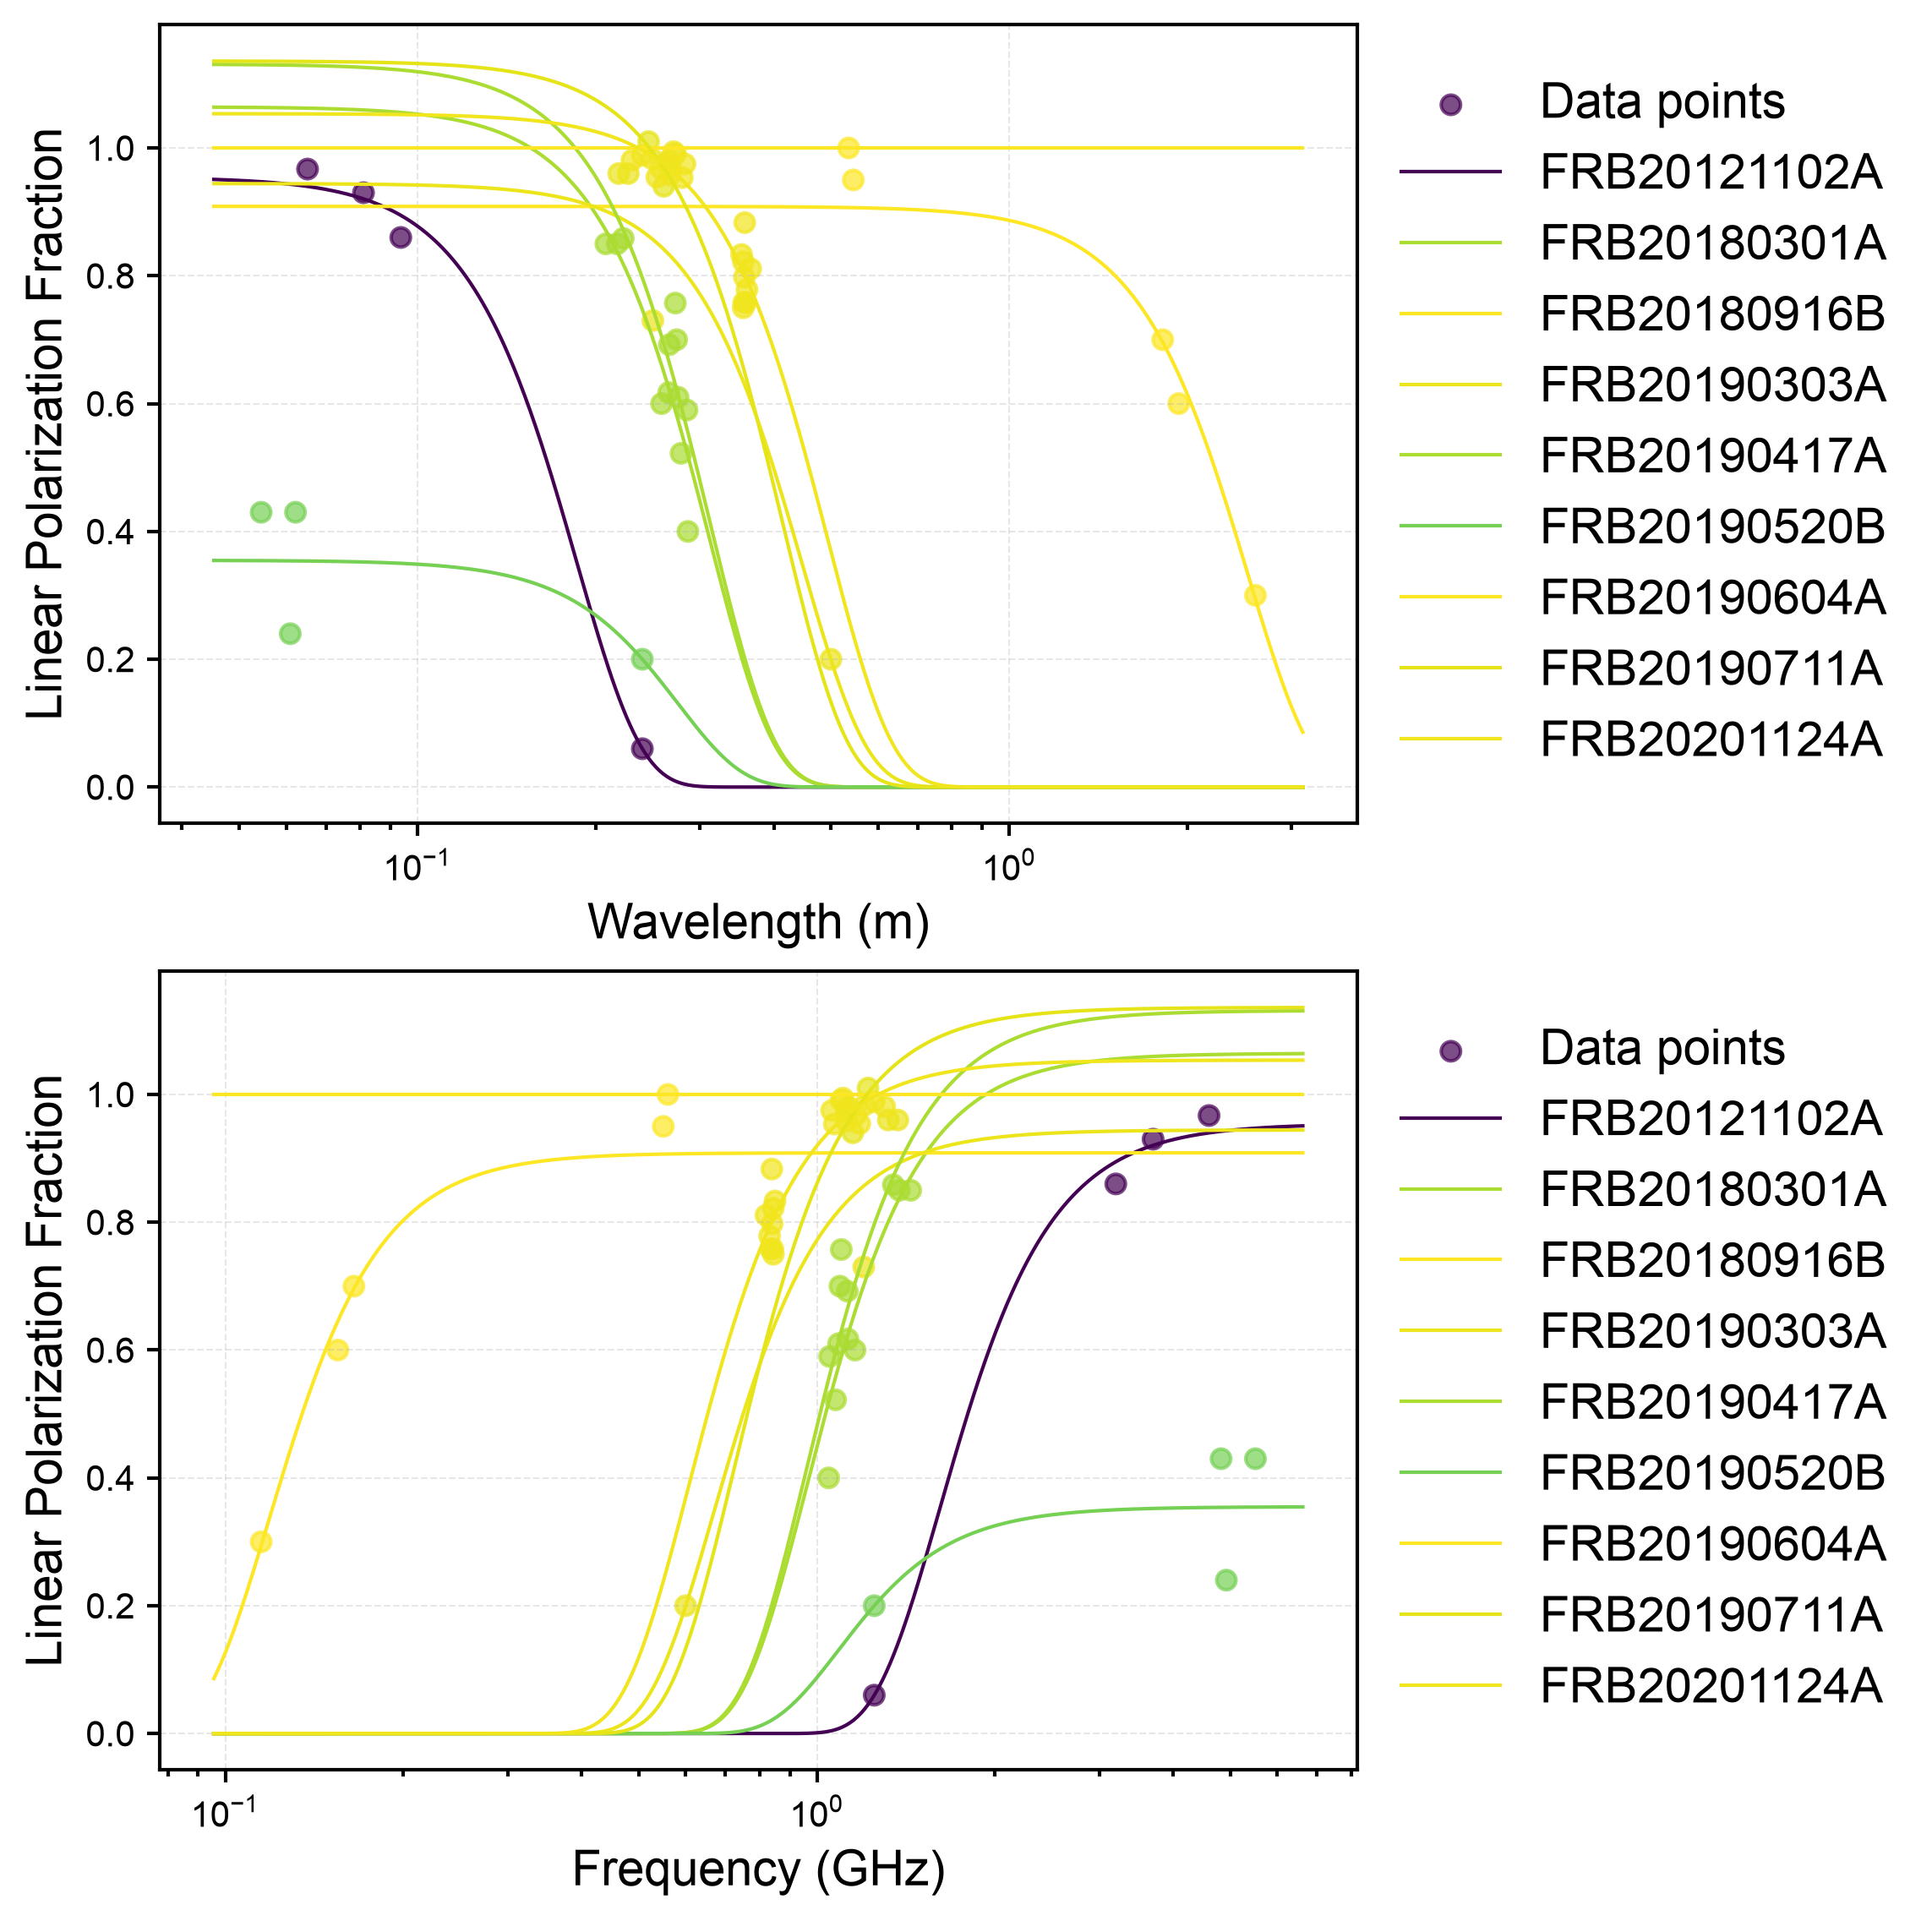

In [137]:
from sr_agent.utils.plot import get_fig

fi, fig, axes = get_fig(2, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)

ax = axes[0]
cmap = lambda source: model['source_to_params'][source]['b']
norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

x = data['lambda_m']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model['source_to_params']:
    p = model['source_to_params'][key]
    yy = np.exp(p['a'] + p['b'] * xx**4)
    color = plt.cm.viridis(norm(p['b']))
    label = key  # f"{key}: LPF = exp({p['a']:.6f} + {p['b']:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))

ax = axes[1]
cmap = lambda source: model['source_to_params'][source]['b']
norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

data['frequency_mhz'] = 299792458.0 / data['lambda_m'] / 1e9
x = data['frequency_mhz']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model['source_to_params']:
    p = model['source_to_params'][key]
    yy = np.exp(p['a'] + p['b'] * (299792458/xx/1e9)**4)
    color = plt.cm.viridis(norm(p['b']))
    label = key  # f"{key}: LPF = exp({p['a']:.6f} + {p['b']:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))

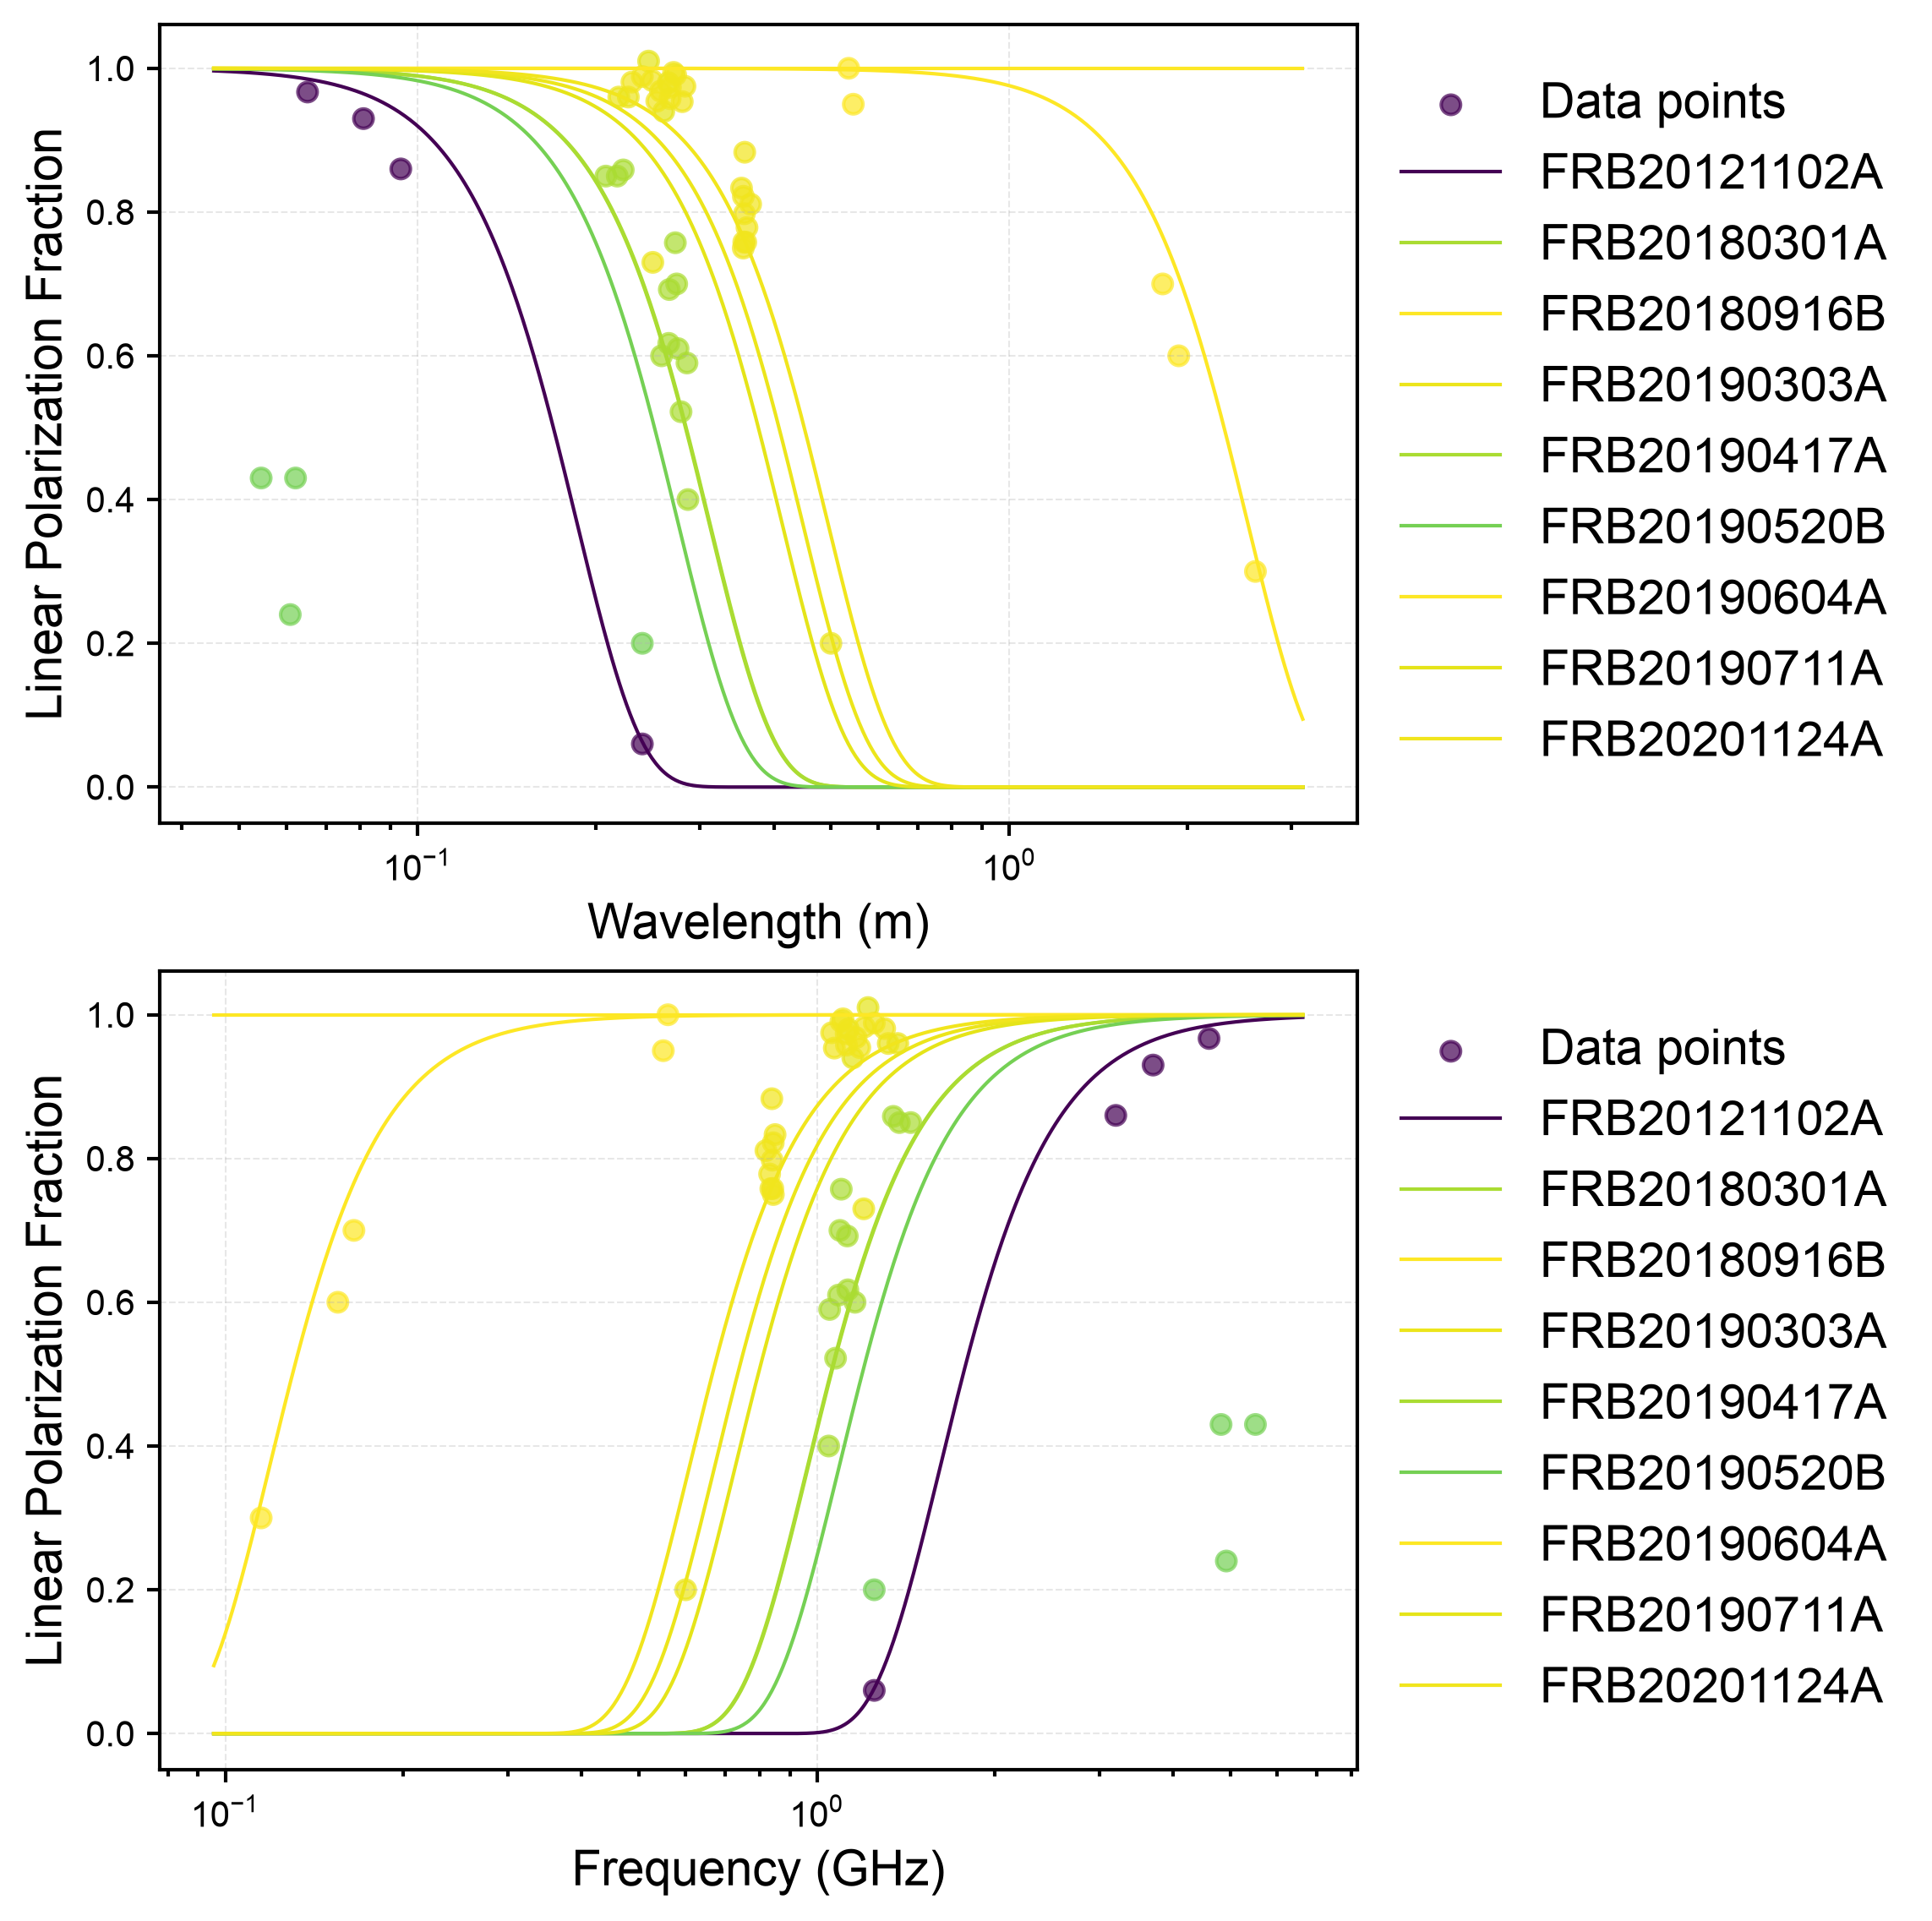

In [139]:
from sr_agent.utils.plot import get_fig

fi, fig, axes = get_fig(2, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)

ax = axes[0]
cmap = lambda source: model2[source][1]
norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

x = data['lambda_m']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model2:
    p = model2[key]
    yy = np.exp(p[0] + p[1] * xx**4)
    color = plt.cm.viridis(norm(p[1]))
    label = key  # f"{key}: LPF = exp({p[0]:.6f} + {p[1]:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))


ax = axes[1]
cmap = lambda source: model2[source][1]
norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

data['frequency_mhz'] = 299792458.0 / data['lambda_m'] / 1e9
x = data['frequency_mhz']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model2:
    p = model2[key]
    yy = np.exp(p[0] + p[1] * (299792458/xx/1e9)**4)
    color = plt.cm.viridis(norm(p[1]))
    label = key  # f"{key}: LPF = exp({p[0]:.6f} + {p[1]:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))

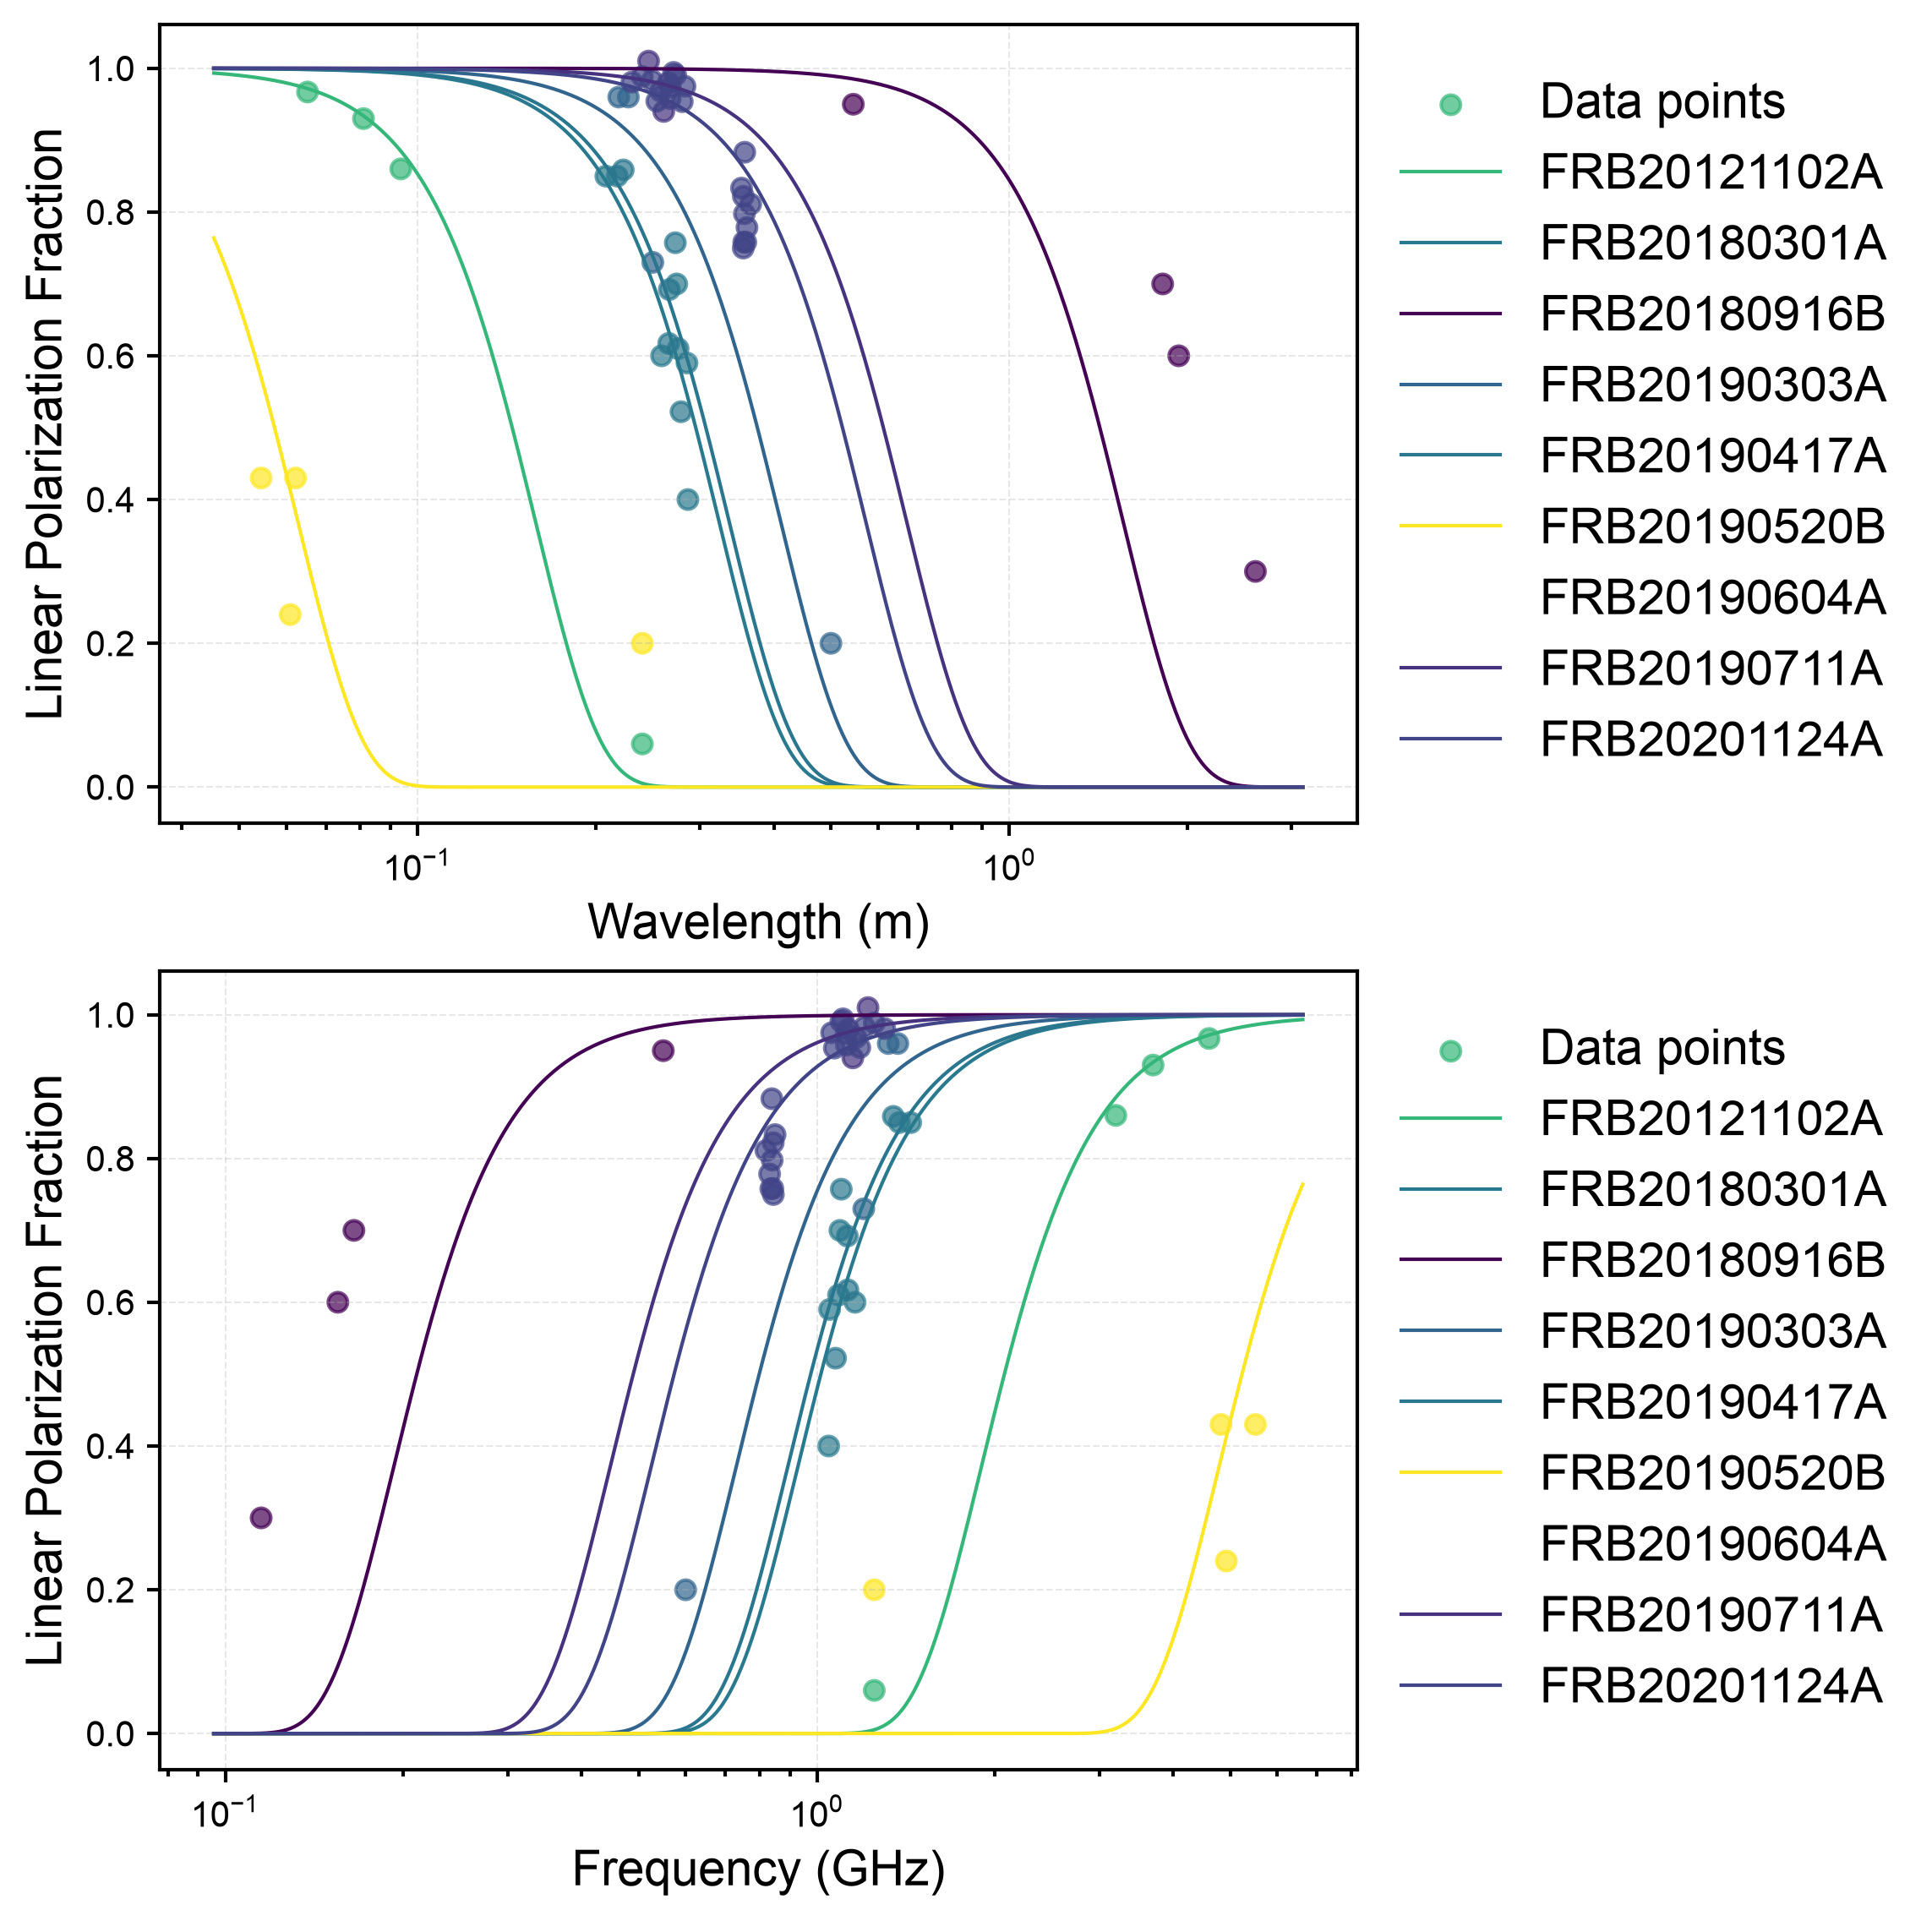

In [154]:
import matplotlib.colors as mcolors
from sr_agent.utils.plot import get_fig

fi, fig, axes = get_fig(2, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)

ax = axes[0]
cmap = lambda source: model3['K_vals'][model3['source_to_idx'][source]]
# norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))
norm = mcolors.LogNorm(vmin=1 + min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

x = data['lambda_m']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model3['source_to_idx']:
    K = model3['K_vals'][model3['source_to_idx'][key]]
    yy = np.exp(-K * xx**4)
    color = plt.cm.viridis(norm(K))
    label = key  # f"{key}: LPF = exp({K:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))


ax = axes[1]
cmap = lambda source: model3['K_vals'][model3['source_to_idx'][source]]
# norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))
norm = mcolors.LogNorm(vmin=1 + min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

data['frequency_mhz'] = 299792458.0 / data['lambda_m'] / 1e9
x = data['frequency_mhz']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model3['source_to_idx']:
    K = model3['K_vals'][model3['source_to_idx'][key]]
    yy = np.exp(-K * (299792458.0/xx/1e9)**4)
    color = plt.cm.viridis(norm(K))
    label = key  # f"{key}: LPF = exp({K:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))

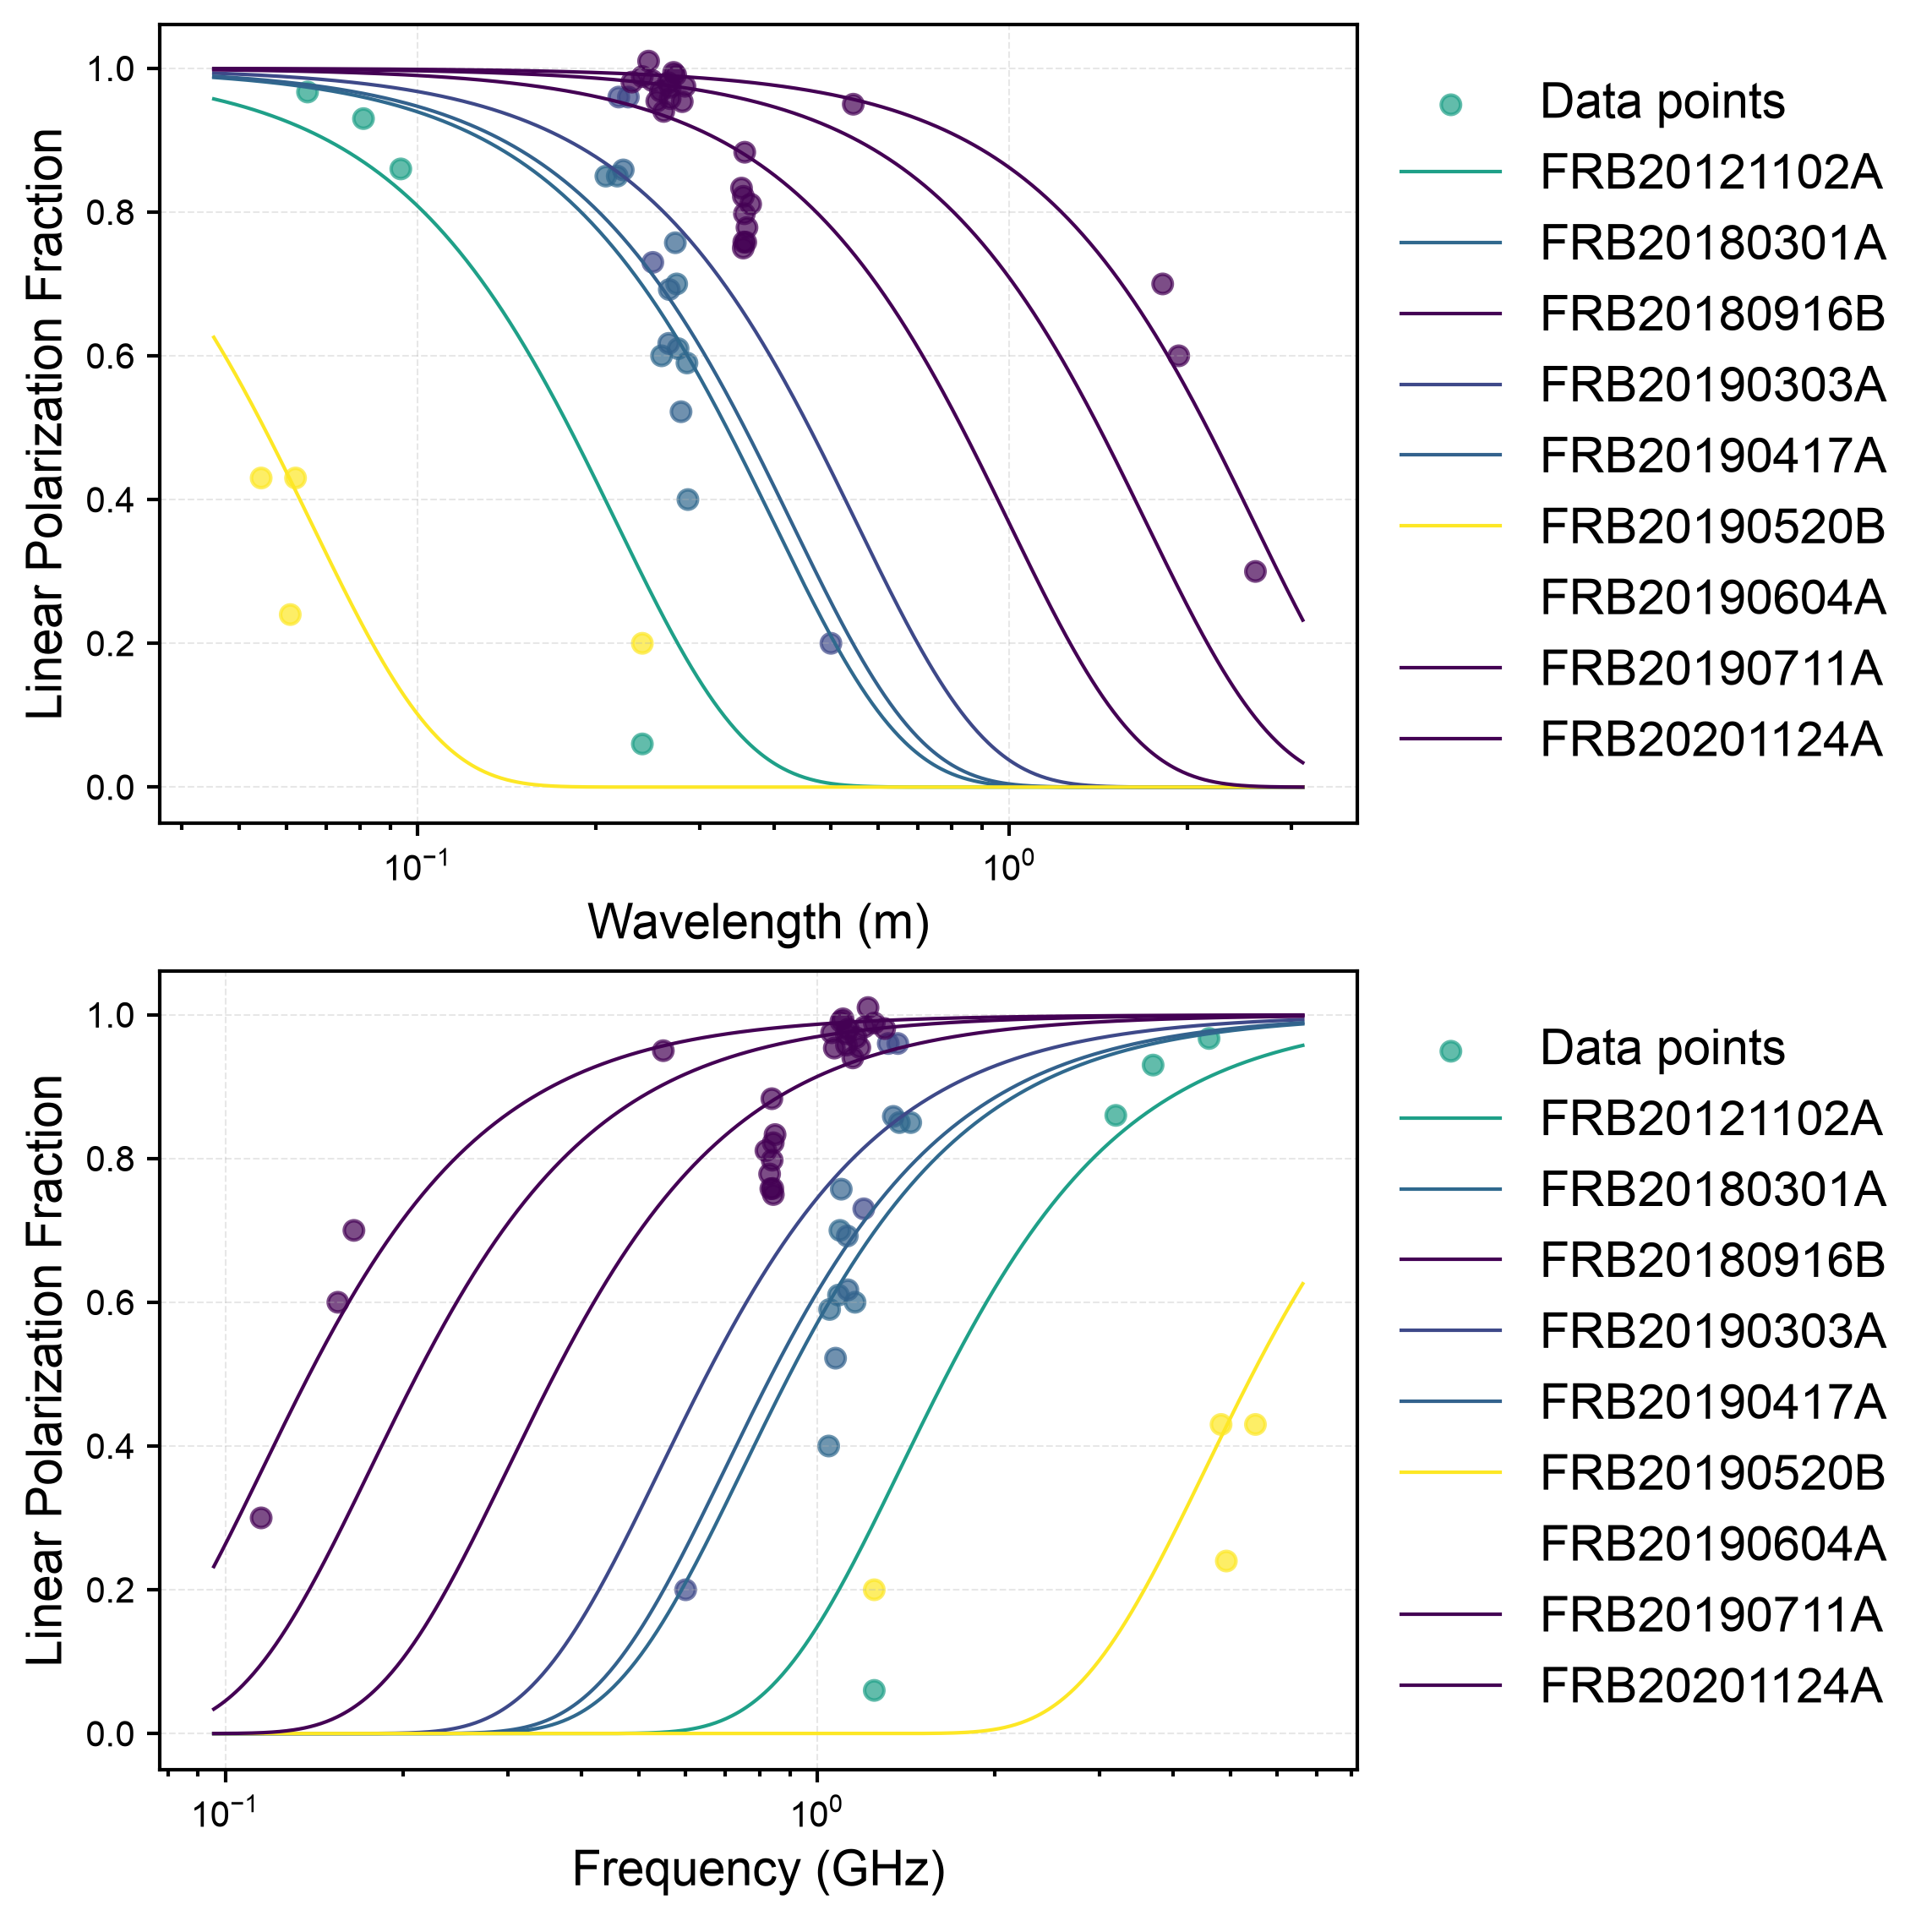

In [162]:
import matplotlib.colors as mcolors
from sr_agent.utils.plot import get_fig

fi, fig, axes = get_fig(2, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)

ax = axes[0]
cmap = lambda source: model4['K'][model4['source_to_idx'][source]]
# norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))
norm = mcolors.LogNorm(vmin=1 + min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

x = data['lambda_m']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model4['source_to_idx']:
    K = model4['K'][model4['source_to_idx'][key]]
    yy = np.exp(-K * xx**2)
    color = plt.cm.viridis(norm(K))
    label = key  # f"{key}: LPF = exp({K:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))


ax = axes[1]
cmap = lambda source: model4['K'][model4['source_to_idx'][source]]
# norm = plt.Normalize(vmin=min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))
norm = mcolors.LogNorm(vmin=1 + min(cmap(s) for s in data['source']), vmax=max(cmap(s) for s in data['source']))

data['frequency_mhz'] = 299792458.0 / data['lambda_m'] / 1e9
x = data['frequency_mhz']
y = data['linear_polarization_fraction']
ax.scatter(x, y, c=[cmap(s) for s in data['source']], s=30, alpha=0.7, norm=norm, cmap='viridis', label='Data points')

xx = np.logspace(np.log10(x.min()) - 0.08, np.log10(x.max()) + 0.08, 600)
for key in model4['source_to_idx']:
    K = model4['K'][model4['source_to_idx'][key]]
    yy = np.exp(-K * (299792458.0/xx/1e9)**2)
    color = plt.cm.viridis(norm(K))
    label = key  # f"{key}: LPF = exp({K:.6f}*lambda^4)"
    ax.plot(xx, yy, label=label, color=color)

ax.semilogx()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Linear Polarization Fraction')
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='center left', fontsize=14, frameon=False, bbox_to_anchor=(1, 0.5))